In [1]:
import pandas as pd
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
import logging
import datetime
import time

from datetime import datetime

from pyspark.sql.functions import col, datediff
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import calendar
import pandas as pd
import plotly.express as px
from pyspark.sql import SparkSession
from pyspark.sql.functions import concat, col
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from ipywidgets import interact, widgets
from matplotlib.dates import MonthLocator, DateFormatter
import geopandas as gpd
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
#from fbprophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np
import plotly.graph_objects as go
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month
from sklearn.metrics.pairwise import euclidean_distances
from pyspark.sql.functions import year, month, sum as sum_
from scipy.spatial.distance import euclidean
from prophet import Prophet
from pyspark.sql.functions import col, countDistinct , desc , count , length
from pyspark.sql.functions import split, col, when
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, dayofmonth, last_day ,to_date, lit, isnull
from pyspark.sql.types import IntegerType
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from dateutil.relativedelta import relativedelta
from pyspark.sql.functions import date_format

from pyspark.sql.functions import col, coalesce, current_date, months_between, round
from pyspark.sql.functions import regexp_replace

import schedule
from pyspark.sql.functions import col, to_timestamp, date_format

import pyspark
import pandas as pd
import boto3
import sagemaker
import sagemaker.feature_store.feature_store as fs
import databricks.connect
from dateutil.relativedelta import relativedelta

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.metrics import mean_squared_error, root_mean_squared_error

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import plotly.graph_objects as go
from itertools import product
import random
import statsmodels.api as sm
import os

from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, months_between, current_date,expr
from pyspark.sql.functions import col, substr

import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
from databricks.connect import DatabricksSession


# Get spark
spark = databricks.connect.DatabricksSession.builder.getOrCreate()

c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\pydantic\_internal\_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[02/19/25 13:54:17] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=535829;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py\credentials.py]8;;\:]8;id=832218;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py#1278\1278]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: C:\ProgramData\sagemaker\sagemaker\config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: C:\Users\gusta\AppData\Local\sagemaker\sagemaker\config.yaml


In [2]:
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter
from scipy.special import gamma  # Para calcular a função gama

def analisar_sobrevivencia_kaplan_weibull(tabela_filtrada):
    """
    Filtra a tabela por data_primeiro_boleto menor que um determinado ano
    e aplica análise de sobrevivência com Kaplan-Meier e Weibull.
    
    Parâmetros:
    tabela_spark : DataFrame do PySpark contendo as colunas "data_primeiro_boleto", "anos_contrato" e "churn".
    ano_filtro : int, ano limite para filtrar os dados. Padrão é 2006.
    
    Retorna:
    Exibe o gráfico comparativo das funções de sobrevivência e imprime os tempos de vida esperados.
    """


    # 🔹 Converter os tipos de colunas para análise
    tabela_filtrada = (
        tabela_filtrada
        .withColumn("anos_contrato", col("anos_contrato").cast("double"))
        .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
    )

    # 🔹 Converter para Pandas
    df_pandas = tabela_filtrada.select("anos_contrato", "churn").toPandas()

    if df_pandas.empty:
        print("Nenhum dado disponível após o filtro aplicado.")
        return

    # 🔹 Aplicar Kaplan-Meier
    kmf = KaplanMeierFitter()
    kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

    # 🔹 Aplicar Weibull
    wf = WeibullFitter()
    wf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

    # 🔹 Cálculo do tempo de vida médio para Kaplan-Meier
    tempo_de_vida_esperado_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)

    # 🔹 Cálculo do tempo de vida médio para Weibull
    lambda_wf = wf.lambda_
    rho_wf = wf.rho_
    tempo_de_vida_esperado_weibull = lambda_wf * gamma(1 + 1/rho_wf)

    # 🔹 Exibir resultados
    print(f"Tempo de vida esperado (Kaplan-Meier): {tempo_de_vida_esperado_km:.2f} anos")
    print(f"Tempo de vida esperado (Weibull): {tempo_de_vida_esperado_weibull:.2f} anos")

    # 🔹 Criar gráfico interativo
    fig = go.Figure()

    # Adicionar curva de sobrevivência Weibull
    fig.add_trace(go.Scatter(
        x=wf.survival_function_.index,
        y=wf.survival_function_["Weibull_estimate"],
        mode="lines",
        name="Weibull Survival Function",
        line=dict(color="blue")
    ))

    # Adicionar curva de sobrevivência Kaplan-Meier
    fig.add_trace(go.Scatter(
        x=kmf.survival_function_.index,
        y=kmf.survival_function_["KM_estimate"],
        mode="lines",
        name="Kaplan-Meier Survival Function",
        line=dict(color="red")
    ))

    # Configurar layout
    fig.update_layout(
        title="Comparação das Curvas de Sobrevivência",
        xaxis_title="Tempo (anos)",
        yaxis_title="Probabilidade de Sobrevivência",
        template="plotly_white"
    )

    # Mostrar gráfico
    fig.show()


In [4]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime

def analisar_permanencia_comparada(tabela_sdf):
    """
    Analisa e compara o tempo de permanência dos contratos baseados na data de início e na data do primeiro boleto.

    Parâmetros:
    tabela_sdf (Spark DataFrame): DataFrame do Spark contendo 'data_inicio', 'anos_contrato', 
                                  'data_primeiro_boleto' e 'anos_boleto'.

    Retorno:
    fig (plotly.graph_objects.Figure): Gráfico interativo comparando os tempos de permanência.
    """

    # Filtrar e converter para Pandas os contratos cancelados
    df_contratos = tabela_sdf.filter(tabela_sdf["tipo_saida"] != "ATIVO") \
        .select("data_inicio", "anos_contrato", "data_primeiro_boleto", "anos_boleto") \
        .toPandas()

    # Converter colunas de data para datetime
    df_contratos["data_inicio"] = pd.to_datetime(df_contratos["data_inicio"])
    df_contratos["data_primeiro_boleto"] = pd.to_datetime(df_contratos["data_primeiro_boleto"])

    # Criar colunas com o ano do contrato e o ano do primeiro boleto
    df_contratos["ano_inicio"] = df_contratos["data_inicio"].dt.year
    df_contratos["ano_primeiro_boleto"] = df_contratos["data_primeiro_boleto"].dt.year

    # Obter o ano atual
    ano_atual = datetime.today().year

    # Calcular estatísticas por ano para os contratos
    estatisticas_contratos = df_contratos.groupby("ano_inicio")["anos_contrato"].agg(["median", "mean"]).reset_index()
    estatisticas_contratos["tempo_maximo_possivel"] = ano_atual - estatisticas_contratos["ano_inicio"]

    # Calcular estatísticas por ano para os boletos
    estatisticas_boletos = df_contratos.groupby("ano_primeiro_boleto")["anos_boleto"].agg(["median", "mean"]).reset_index()
    estatisticas_boletos["tempo_maximo_possivel"] = ano_atual - estatisticas_boletos["ano_primeiro_boleto"]

    # Criar gráfico interativo
    fig = go.Figure()

    # Adicionar linhas dos contratos
    fig.add_trace(go.Scatter(
        x=estatisticas_contratos["ano_inicio"],
        y=estatisticas_contratos["median"],
        mode="lines+markers",
        name="Mediana Contratos",
        line=dict(color="blue")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_contratos["ano_inicio"],
        y=estatisticas_contratos["mean"],
        mode="lines+markers",
        name="Média Contratos",
        line=dict(color="green")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_contratos["ano_inicio"],
        y=estatisticas_contratos["tempo_maximo_possivel"],
        mode="lines",
        name="Tempo Máximo Contratos",
        line=dict(color="red", dash="dash")
    ))

    # Adicionar linhas dos boletos
    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["median"],
        mode="lines+markers",
        name="Mediana Boletos",
        line=dict(color="purple")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["mean"],
        mode="lines+markers",
        name="Média Boletos",
        line=dict(color="orange")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["tempo_maximo_possivel"],
        mode="lines",
        name="Tempo Máximo Boletos",
        line=dict(color="brown", dash="dash")
    ))

    # Layout do gráfico
    fig.update_layout(
        title="Comparação do Tempo de Permanência: Contratos vs. Boletos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Permanência (anos)",
        showlegend=True,
        xaxis=dict(
            dtick=1,
            tickmode='linear'
        )
    )

    return fig



In [4]:
cliente = spark.table("prd.dl_redeok_checkok.tb_cliente") # Tabela com data inici, data final , motivo do bloqueio e max_conexao = next_status , cnpj
revenda = spark.table("prd.dl_redeok_checkok.tb_revenda") # Só usamos para filtrar os contratos tipo revenda
receber = spark.table("prd.dl_redeok_checkok.vw_receber") # Tabela de faturas
estab_df = spark.table("prd.dl_receita_federal.tb_estabelecimento").alias("estab") \
    .withColumn("CNPJ_CPF", concat(col("cnpj_basico"), col("cnpj_ordem"), col("cnpj_dv")))
hierarquia_sdf = spark.table("dev.dw_rok.tb_cnae_hierarquia_comercial").alias("hierarquia")


In [5]:
# Selecionar as colunas desejadas no estab_df
estab_selected = estab_df.select("CNPJ_CPF", "cnae_fiscal_principal","uf","data_inicio_atividade")

# Realizar o join com hierarquia_sdf utilizando a coluna cnae_fiscal_principal e CNAE_RF
resultado_df = estab_selected.join(hierarquia_sdf, estab_selected["cnae_fiscal_principal"] == hierarquia_sdf["CNAE_RF"], "left")

# Suponha que df seja seu DataFrame
#resultado_df = resultado_df.withColumn("ano_nascimento", substr(col("data_inicio_atividade"), 1, 4))

resultado_df = resultado_df.select("CNPJ_CPF", "CNAE_RF", "Hierarquia","uf","data_inicio_atividade")


In [7]:
query=  """WITH 
-- CTE para obter informações básicas dos clientes, como quantidade de contratos, primeiro e último bloqueio, motivo e status de conexão
clientes AS 
(
    SELECT 
          COUNT(1)              AS contratos          -- Contagem total de contratos por documento
        , cgcmf                 AS documento          -- Documento do cliente (CNPJ)
        , MIN(data_cad)         AS data_inicio        -- Data de início do primeiro contrato do cliente
        , MAX(bloqueio)         AS data_final         -- Data do último bloqueio do cliente
        , MAX_BY(max_conexao, bloqueio) AS max_conexao        -- Status de conexão mais recente
    FROM 
    (
        -- Seleção dos clientes únicos, eliminando duplicatas e aplicando filtros iniciais
        SELECT DISTINCT
            matriz, codigo, fis_jurid, cgcmf, raz_social, max_conexao, bloqueio, mot_bloqueio,
            sit_cliente, data_cad, vendedor, vlrfatmin, vlr_dispacesso, receita
        FROM 
            prd.dl_redeok_checkok.tb_cliente cli
        WHERE 
            cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')         -- Filtra clientes com status ativos ou pendentes
            AND (cli.matriz = cli.codigo OR falsa = 's')         -- Mantém apenas contas da matriz ou marcadas como falsas
            AND cli.receita IN (9, 10, 46, 58)                   -- Filtra por tipos de receita específico
            AND cli.cgcmf IS NOT NULL                            -- Remove registros sem CNPJ
            AND cli.cgcmf != '23236392000198'                    -- Exclui um CNPJ específico (ROK)
            AND LENGTH(TRIM(cli.cgcmf)) = 14                     -- Garante que o CNPJ tenha 14 caracteres
            AND cli.cgcmf RLIKE '^[0-9]+$'                       -- Garante que o CNPJ seja numérico

            -- Remove registros que fazem parte da tabela de revendas
            AND NOT EXISTS 
            (
                SELECT 1 
                FROM prd.dl_redeok_checkok.tb_revenda rev 
                WHERE cli.codigo = rev.codigo
            )
    ) 
    GROUP BY cgcmf
),

-- CTE para contar a quantidade de boletos gerados por cliente
titulo_cobranca AS 
(
    SELECT 
          documento         AS documento                
        , cliente          AS cliente  
        , COUNT(meses)      AS boletos_gerados        -- Contagem de meses com boletos gerados
    FROM 
    (
    -- Seleção de boletos distintos por cliente e mês
        SELECT DISTINCT
            cli.cgcmf                           AS documento
            , rec.cliente                       AS cliente  
            , DATE_TRUNC('month', rec.emissao)  AS meses     -- Agrupa por mês de emissão do boleto
        FROM 
            prd.dl_redeok_checkok.vw_receber rec
        INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
            ON cli.codigo = rec.cliente
        WHERE 
            rec.situacao IN ('A', 'B')

             -- Remove registros de revendas
            AND NOT EXISTS 
            (
                SELECT 1 
                FROM prd.dl_redeok_checkok.tb_revenda rev 
                WHERE rev.codigo = rec.cliente
            )

             -- Filtra os mesmos clientes da CTE 'clientes'
            AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
            AND (cli.matriz = cli.codigo OR falsa = 's')
            AND cli.receita IN (9, 10, 46, 58)
            AND cli.cgcmf IS NOT NULL
            AND cli.cgcmf != '23236392000198'
            AND LENGTH(TRIM(cli.cgcmf)) = 14    
            AND cli.cgcmf RLIKE '^[0-9]+$'
    ) 
    GROUP BY 
        documento, cliente  
),

-- CTE para encontrar a data do último boleto gerado por cliente
ultimo_boleto AS 
(
    SELECT 
        cli.cgcmf AS documento,
        MAX(rec.emissao) AS ultima_emissao            -- Última data de emissão do boleto
    FROM 
        prd.dl_redeok_checkok.vw_receber rec
    INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
        ON cli.codigo = rec.cliente
    WHERE 
        rec.situacao IN ('A', 'B')                   -- Apenas boletos ativos ou em aberto

        -- Remove registros de revendas
        AND NOT EXISTS 
        (
            SELECT 1 
            FROM prd.dl_redeok_checkok.tb_revenda rev 
            WHERE rev.codigo = rec.cliente
        )
        AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
        AND (cli.matriz = cli.codigo OR falsa = 's')
        AND cli.receita IN (9, 10, 46, 58)
        AND cli.cgcmf IS NOT NULL
        AND cli.cgcmf != '23236392000198'
        AND LENGTH(TRIM(cli.cgcmf)) = 14    
        AND cli.cgcmf RLIKE '^[0-9]+$'
    GROUP BY cli.cgcmf
),

-- CTE para encontrar a data do primeiro boleto gerado por cliente
primeiro_boleto AS 
(
    SELECT 
        cli.cgcmf AS documento,
        MIN(rec.emissao) AS data_primeiro_boleto
    FROM 
        prd.dl_redeok_checkok.vw_receber rec
    INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
        ON cli.codigo = rec.cliente
    WHERE 
        rec.situacao IN ('A', 'B')
        AND NOT EXISTS 
        (
            SELECT 1 
            FROM prd.dl_redeok_checkok.tb_revenda rev 
            WHERE rev.codigo = rec.cliente
        )
        AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
        AND (cli.matriz = cli.codigo OR falsa = 's')
        AND cli.receita IN (9, 10, 46, 58)
        AND cli.cgcmf IS NOT NULL
        AND cli.cgcmf != '23236392000198'
        AND LENGTH(TRIM(cli.cgcmf)) = 14    
        AND cli.cgcmf RLIKE '^[0-9]+$'
    GROUP BY cli.cgcmf
),

-- CTE para somar o total pago por cliente
soma_valor_pago AS
(
    SELECT 
        cli.cgcmf AS documento,
        SUM(rec.valor_pago) AS total_valor_pago       -- Soma total de valores pagos pelo cliente
    FROM 
        prd.dl_redeok_checkok.vw_receber rec
    INNER JOIN prd.dl_redeok_checkok.tb_cliente cli 
        ON cli.codigo = rec.cliente
    WHERE 
        rec.situacao IN ('A', 'B')

        -- Remove registros de revendas
        AND NOT EXISTS 
        (
            SELECT 1 
            FROM prd.dl_redeok_checkok.tb_revenda rev 
            WHERE rev.codigo = rec.cliente
        )
        AND cli.sit_cliente IN ('A', 'F', 'N', 'P', 'D')
        AND (cli.matriz = cli.codigo OR falsa = 's')
        AND cli.receita IN (9, 10, 46, 58)
        AND cli.cgcmf IS NOT NULL
        AND cli.cgcmf != '23236392000198'
        AND LENGTH(TRIM(cli.cgcmf)) = 14    
        AND cli.cgcmf RLIKE '^[0-9]+$'
    GROUP BY cli.cgcmf
),
documentos_filtrados AS (
    SELECT 
          cli.contratos
        , cli.documento
        , tit.cliente  
        , cli.data_inicio
        , cli.data_final  
        , cli.max_conexao 
        , prim.data_primeiro_boleto   
        , CASE 
              WHEN cli.data_final IS NULL THEN NULL
              ELSE ult.ultima_emissao
          END AS data_ultimo_boleto
        , tit.boletos_gerados
        , ROUND(COALESCE(soma.total_valor_pago, 0), 1) AS total_valor_pago
        , ROW_NUMBER() OVER (PARTITION BY cli.documento ORDER BY tit.boletos_gerados DESC) AS row_number
     FROM 
        clientes cli
    INNER JOIN titulo_cobranca tit 
        ON cli.documento = tit.documento
    LEFT JOIN ultimo_boleto ult
        ON cli.documento = ult.documento
    LEFT JOIN primeiro_boleto prim
        ON cli.documento = prim.documento
    LEFT JOIN soma_valor_pago soma
        ON cli.documento = soma.documento
)
SELECT 
    contratos,
    documento,
    cliente,
    data_inicio,
    data_final,
    max_conexao,
    data_primeiro_boleto,
    data_ultimo_boleto,
    boletos_gerados,
    total_valor_pago
FROM documentos_filtrados
WHERE row_number = 1;

"""


# Executando a consulta e obtendo os dados em um DataFrame Spark
tabela_nova_sdf= spark.sql(query)

from pyspark.sql.functions import round

# Criar a coluna 'tipo_saida' com as condições especificadas
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "tipo_saida",
    F.when(F.col("max_conexao") == -1, "CANCELAMENTO NORMAL")
    .when(F.col("max_conexao") == 0, "90 DIAS BLOQUEADO")
    .when(F.col("max_conexao") == -5, "90 DIAS PRÉ CANCELADO")
    .when(F.col("max_conexao") == -7, "90 DIAS PRÉ CANCELADO JURÍDICO")
    .when(F.col("max_conexao").isNull(), "ATIVO")
    .otherwise("OUTROS")
)



from pyspark.sql.functions import col, to_date

from pyspark.sql.functions import col, to_timestamp

# Corrigir datas que possuem o ano como '0012' para '2012' e '0017' para '2017'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0011-", "2011-")  # Corrige 0012 para 2012
)


# Corrigir datas que possuem o ano como '0012' para '2012' e '0017' para '2017'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0201-", "2019-")  # Corrige 0012 para 2012
)

# Corrigir datas que possuem o ano como '0012' para '2012' e '0017' para '2017'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0012-", "2012-")  # Corrige 0012 para 2012
)

tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "data_final", 
    regexp_replace("data_final", "^0017-", "2017-")  # Corrige 0017 para 2017
)

# Adicionar o cálculo do meses_contrato tratando data_final nulo
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "meses_contrato",
    round(
        months_between(
            # Usa a data atual quando data_final for nulo
            coalesce(col("data_final"), current_date()),
            col("data_inicio")
        )
    )
)

# Criar a coluna 'meses_boleto'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "meses_boleto",
    F.round(
        F.months_between(
            F.coalesce(F.col("data_ultimo_boleto"), F.current_date()),  # Se for nulo, usa a data atual
            F.col("data_primeiro_boleto")
        ), 2  # Arredonda para 2 casas decimais
    )
)

# Criar a coluna 'anos_boleto'
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "anos_boleto",
    F.round(
        F.months_between(
            F.coalesce(F.col("data_ultimo_boleto"), F.current_date()),  # Corrigido para F.col(...)
            F.col("data_primeiro_boleto")  # Corrigido para F.col(...)
        ) / 12, 2  # Divide por 12 para converter para anos e arredonda para 2 casas decimais
    )
)
tabela_nova_sdf = tabela_nova_sdf.withColumn("anos_contrato", round(col("meses_contrato") / 12, 2))

tabela_nova_sdf = tabela_nova_sdf.withColumn("churn",when(col("data_final").isNotNull(), 1).otherwise(0))

tabela_nova_sdf = tabela_nova_sdf.withColumn("ano_inicio", year(col("data_inicio"))) 


tabela_nova_sdf = tabela_nova_sdf.filter(col("contratos") == 1)

# Substituir valores nulos pela data atual
# Criar colunas corrigindo a diferença para ser sempre positiva
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "diferenca_meses_inicio_primeiro_boleto",
    expr("ceil(abs(months_between(data_primeiro_boleto, data_inicio)))")
).withColumn(
    "diferenca_meses_final_ultimo_boleto",
    expr("abs(floor(months_between(COALESCE(data_final, current_date()), COALESCE(data_ultimo_boleto, current_date()))))")
)

from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, expr

# Criar a classificação para diferença de meses
tabela_nova_sdf = tabela_nova_sdf.withColumn(
    "classifica_diferenca_boleto_tempo_inicial",
    when(col("diferenca_meses_inicio_primeiro_boleto") <= 1, "0 a 1 mês")
    .when((col("diferenca_meses_inicio_primeiro_boleto") >= 2) & (col("diferenca_meses_inicio_primeiro_boleto") <= 5), "2 a 5 meses")
    .when((col("diferenca_meses_inicio_primeiro_boleto") >= 6) & (col("diferenca_meses_inicio_primeiro_boleto") <= 12), "6 a 12 meses")
    .when((col("diferenca_meses_inicio_primeiro_boleto") > 12) & (col("diferenca_meses_inicio_primeiro_boleto") <= 24), "13 a 24 meses")
    .otherwise("Maior que 24 meses")
).withColumn(
    "classifica_diferenca_boleto_tempo_final",
    when(col("diferenca_meses_final_ultimo_boleto") <= 1, "0 a 1 mês")
    .when((col("diferenca_meses_final_ultimo_boleto") >= 2) & (col("diferenca_meses_final_ultimo_boleto") <= 5), "2 a 5 meses")
    .when((col("diferenca_meses_final_ultimo_boleto") >= 6) & (col("diferenca_meses_final_ultimo_boleto") <= 12), "6 a 12 meses")
    .when((col("diferenca_meses_final_ultimo_boleto") > 12) & (col("diferenca_meses_final_ultimo_boleto") <= 24), "13 a 24 meses")
    .otherwise("Maior que 24 meses")
)

tabela_nova_sdf = tabela_nova_sdf.filter((col("meses_contrato") > 0))

# Pegando o ano das datas
#df = tabela_nova_sdf.withColumn("ano_primeiro_boleto", year(col("data_primeiro_boleto"))) \
       #.withColumn("ano_ultimo_boleto", year(col("data_ultimo_boleto")))

tabela_nova_sdf = tabela_nova_sdf.filter(
    (year(col("data_primeiro_boleto")).isNotNull()) & 
    (year(col("data_primeiro_boleto")) >= 1900) & 
    ((col("data_ultimo_boleto").isNull()) | (year(col("data_ultimo_boleto")) >= 1900)) &  
    (year(col("data_primeiro_boleto")) <= 2100) & 
    ((col("data_ultimo_boleto").isNull()) | (year(col("data_ultimo_boleto")) <= 2100))
)





In [8]:
# Realizar o join entre tabela_nova_sdf e resultado_df usando documento = CNPJ_CPF
tabela_nova_sdf = tabela_nova_sdf.join(resultado_df, tabela_nova_sdf["documento"] == resultado_df["CNPJ_CPF"], "left")

In [9]:
from pyspark.sql.functions import to_timestamp

tabela_nova_sdf = tabela_nova_sdf.withColumn("data_inicio", to_date(tabela_nova_sdf["data_inicio"], "yyyy-MM-dd HH:mm:ss"))
tabela_nova_sdf = tabela_nova_sdf.withColumn("data_final", to_date(tabela_nova_sdf["data_final"], "yyyy-MM-dd HH:mm:ss"))
tabela_nova_sdf = tabela_nova_sdf.withColumn("data_primeiro_boleto", to_date(tabela_nova_sdf["data_primeiro_boleto"], "yyyy-MM-dd HH:mm:ss"))
tabela_nova_sdf = tabela_nova_sdf.withColumn("data_ultimo_boleto", to_date(tabela_nova_sdf["data_ultimo_boleto"], "yyyy-MM-dd HH:mm:ss"))


In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, substring, year, current_date, when

# Obter o ano e calcular a idade
tabela_nova_sdf = tabela_nova_sdf.withColumn("ano_inicio_atividade", when(col("data_inicio_atividade").isNotNull(), substring(col("data_inicio_atividade"), 1, 4).cast("int"))) \
       .withColumn("idade", when(col("ano_inicio").isNotNull(), year(current_date()) - col("ano_inicio_atividade")))

# Mostrar resultado
#tabela_nova_sdf.show()

In [11]:
#x = x.select("contratos", "documento", "cliente","ano_inicio","data_inicio","data_final","data_primeiro_boleto","data_ultimo_boleto",
                                         #"anos_boleto","anos_contrato","meses_boleto","meses_contrato","max_conexao","tipo_saida", "boletos_gerados","total_valor_pago","churn",
                                        # "diferenca_meses_inicio_primeiro_boleto","diferenca_meses_final_ultimo_boleto","classifica_diferenca_boleto_tempo_inicial","classifica_diferenca_boleto_tempo_final","Hierarquia","uf","data_inicio_atividade","data_inicio_atividade")  


In [11]:
# Exibir o schema do DataFrame
tabela_nova_sdf.printSchema()

root
 |-- contratos: long (nullable = false)
 |-- documento: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- data_inicio: date (nullable = true)
 |-- data_final: date (nullable = true)
 |-- max_conexao: string (nullable = true)
 |-- data_primeiro_boleto: date (nullable = true)
 |-- data_ultimo_boleto: date (nullable = true)
 |-- boletos_gerados: long (nullable = false)
 |-- total_valor_pago: double (nullable = true)
 |-- tipo_saida: string (nullable = false)
 |-- meses_contrato: double (nullable = true)
 |-- meses_boleto: double (nullable = true)
 |-- anos_boleto: double (nullable = true)
 |-- anos_contrato: double (nullable = true)
 |-- churn: integer (nullable = false)
 |-- ano_inicio: integer (nullable = true)
 |-- diferenca_meses_inicio_primeiro_boleto: long (nullable = true)
 |-- diferenca_meses_final_ultimo_boleto: long (nullable = true)
 |-- classifica_diferenca_boleto_tempo_inicial: string (nullable = false)
 |-- classifica_diferenca_boleto_tempo_final: str

In [13]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter

def analisar_sobrevivencia_kaplan(tabela_filtrada):
    """
    Para cada ano a partir de 2006 até 2024, calcula o tempo médio esperado de sobrevivência usando Kaplan-Meier,
    considerando apenas contratos com data_inicio maior ou igual ao ano filtrado.

    Parâmetros:
    - tabela_filtrada: DataFrame do PySpark contendo as colunas "data_inicio", "data_primeiro_boleto", "anos_contrato" e "churn".

    Retorna:
    - Gráfico com a evolução do tempo médio esperado ao longo dos anos.
    """
    
    # 🔹 Definir intervalo de anos
    ano_min = 2006
    ano_max = 2024
    
    resultados = []
    
    for ano_filtro in range(ano_min, ano_max + 1):
        print(f"Calculando para contratos com data_inicio após {ano_filtro}...")
        
        # 🔹 Filtrar contratos com data_inicio maior ou igual ao ano selecionado e garantir que data_primeiro_boleto não seja menor que data_inicio
        df_filtrado = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )
        
        # 🔹 Converter colunas para tipos adequados
        df_filtrado = (
            df_filtrado
            .withColumn("anos_contrato", col("anos_contrato").cast("double"))
            .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
        )
        
        # 🔹 Converter para Pandas
        df_pandas = df_filtrado.select("anos_contrato", "churn").toPandas()
        
        if df_pandas.empty:
            continue
        
        # 🔹 Aplicar Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])
        
        # 🔹 Calcular o tempo de vida esperado
        tempo_de_vida_esperado = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        
        resultados.append((ano_filtro, tempo_de_vida_esperado))
    
    # 🔹 Converter resultados em DataFrame
    df_resultados = pd.DataFrame(resultados, columns=["Ano", "Tempo de Vida Esperado"])
    
    # 🔹 Criar gráfico
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df_resultados["Ano"],
        y=df_resultados["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Tempo Médio Esperado",
        line=dict(color="red")
    ))
    
    fig.update_layout(
        title="Evolução do Tempo de Vida Esperado ao Longo dos Anos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white"
    )
    
    fig.show()


In [14]:
analisar_sobrevivencia_kaplan(tabela_nova_sdf)

Calculando para contratos com data_inicio após 2006...
Calculando para contratos com data_inicio após 2007...
Calculando para contratos com data_inicio após 2008...
Calculando para contratos com data_inicio após 2009...
Calculando para contratos com data_inicio após 2010...
Calculando para contratos com data_inicio após 2011...
Calculando para contratos com data_inicio após 2012...
Calculando para contratos com data_inicio após 2013...
Calculando para contratos com data_inicio após 2014...
Calculando para contratos com data_inicio após 2015...
Calculando para contratos com data_inicio após 2016...
Calculando para contratos com data_inicio após 2017...
Calculando para contratos com data_inicio após 2018...
Calculando para contratos com data_inicio após 2019...
Calculando para contratos com data_inicio após 2020...
Calculando para contratos com data_inicio após 2021...
Calculando para contratos com data_inicio após 2022...
Calculando para contratos com data_inicio após 2023...
Calculando

In [17]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter

def analisar_sobrevivencia_kaplan_semativos(tabela_filtrada):
    """
    Para cada ano a partir de 2006 até 2024, calcula o tempo médio esperado de sobrevivência usando Kaplan-Meier,
    considerando apenas contratos com data_inicio maior ou igual ao ano filtrado.

    Parâmetros:
    - tabela_filtrada: DataFrame do PySpark contendo as colunas "data_inicio", "data_primeiro_boleto", "anos_contrato" e "churn".

    Retorna:
    - Gráfico com a evolução do tempo médio esperado ao longo dos anos.
    """
    
    # 🔹 Definir intervalo de anos
    ano_min = 2006
    ano_max = 2024
    
    resultados = []
    
    for ano_filtro in range(ano_min, ano_max + 1):
        print(f"Calculando para contratos com data_inicio após {ano_filtro}...")
        
        # 🔹 Filtrar contratos com data_inicio maior ou igual ao ano selecionado e garantir que data_primeiro_boleto não seja menor que data_inicio
        df_filtrado = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & (year(col("data_primeiro_boleto")) >= year(col("data_inicio"))) & (col("tipo_saida") != "ATIVO")
        )
        
        # 🔹 Converter colunas para tipos adequados
        df_filtrado = (
            df_filtrado
            .withColumn("anos_contrato", col("anos_contrato").cast("double"))
            .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
        )
        
        # 🔹 Converter para Pandas
        df_pandas = df_filtrado.select("anos_contrato", "churn").toPandas()
        
        if df_pandas.empty:
            continue
        
        # 🔹 Aplicar Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])
        
        # 🔹 Calcular o tempo de vida esperado
        tempo_de_vida_esperado = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        
        resultados.append((ano_filtro, tempo_de_vida_esperado))
    
    # 🔹 Converter resultados em DataFrame
    df_resultados = pd.DataFrame(resultados, columns=["Ano", "Tempo de Vida Esperado"])
    
    # 🔹 Criar gráfico
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df_resultados["Ano"],
        y=df_resultados["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Tempo Médio Esperado",
        line=dict(color="red")
    ))
    
    fig.update_layout(
        title="Evolução do Tempo de Vida Esperado ao Longo dos Anos - Sem Ativos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white"
    )
    
    fig.show()


In [18]:
analisar_sobrevivencia_kaplan_semativos(tabela_nova_sdf)

Calculando para contratos com data_inicio após 2006...
Calculando para contratos com data_inicio após 2007...
Calculando para contratos com data_inicio após 2008...
Calculando para contratos com data_inicio após 2009...
Calculando para contratos com data_inicio após 2010...
Calculando para contratos com data_inicio após 2011...
Calculando para contratos com data_inicio após 2012...
Calculando para contratos com data_inicio após 2013...
Calculando para contratos com data_inicio após 2014...
Calculando para contratos com data_inicio após 2015...
Calculando para contratos com data_inicio após 2016...
Calculando para contratos com data_inicio após 2017...
Calculando para contratos com data_inicio após 2018...
Calculando para contratos com data_inicio após 2019...
Calculando para contratos com data_inicio após 2020...
Calculando para contratos com data_inicio após 2021...
Calculando para contratos com data_inicio após 2022...
Calculando para contratos com data_inicio após 2023...
Calculando

In [21]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter

def analisar_sobrevivencia_kaplan_todos(tabela_filtrada):
    """
    Para cada ano de 2006 até 2024, calcula o tempo médio esperado de sobrevivência usando Kaplan-Meier,
    considerando dois cenários:
    1. Apenas contratos onde tipo_saida != "ATIVO".
    2. Todos os contratos.

    Retorna:
    - Gráfico comparando a evolução do tempo médio esperado ao longo dos anos para ambos os cenários.
    """

    # 🔹 Definir intervalo de anos
    ano_min = 2006
    ano_max = 2024

    resultados_filtrados = []
    resultados_todos = []

    for ano_filtro in range(ano_min, ano_max + 1):
        print(f"Calculando para contratos com data_inicio após {ano_filtro}...")

        # 🔹 Filtro 1: Apenas contratos que não são "ATIVO"
        df_filtrado = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio"))) & 
            (col("tipo_saida") != "ATIVO")
        )

        # 🔹 Filtro 2: Todos os contratos
        df_todos = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )

        # 🔹 Converter colunas para tipos adequados e transformar para Pandas
        for df, resultados in [(df_filtrado, resultados_filtrados), (df_todos, resultados_todos)]:
            df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
                   .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
            
            df_pandas = df.select("anos_contrato", "churn").toPandas()

            if df_pandas.empty:
                continue
            
            # 🔹 Aplicar Kaplan-Meier
            kmf = KaplanMeierFitter()
            kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

            # 🔹 Calcular o tempo médio de vida esperado
            tempo_de_vida_esperado = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
            
            resultados.append((ano_filtro, tempo_de_vida_esperado))

    # 🔹 Criar DataFrames de resultados
    df_resultados_filtrados = pd.DataFrame(resultados_filtrados, columns=["Ano", "Tempo de Vida Esperado"])
    df_resultados_todos = pd.DataFrame(resultados_todos, columns=["Ano", "Tempo de Vida Esperado"])

    # 🔹 Criar gráfico comparativo
    fig = go.Figure()

    # 🔹 Adicionar linha para contratos sem "ATIVO"
    fig.add_trace(go.Scatter(
        x=df_resultados_filtrados["Ano"].astype(str),
        y=df_resultados_filtrados["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Sem ATIVO",
        line=dict(color="red")
    ))

    # 🔹 Adicionar linha para todos os contratos
    fig.add_trace(go.Scatter(
        x=df_resultados_todos["Ano"].astype(str),
        y=df_resultados_todos["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Todos os Contratos",
        line=dict(color="blue")
    ))

    fig.update_layout(
        title="Evolução do Tempo de Vida Esperado ao Longo dos Anos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Filtragem"
    )

    fig.show()


In [22]:
analisar_sobrevivencia_kaplan_todos(tabela_nova_sdf)

Calculando para contratos com data_inicio após 2006...
Calculando para contratos com data_inicio após 2007...
Calculando para contratos com data_inicio após 2008...
Calculando para contratos com data_inicio após 2009...
Calculando para contratos com data_inicio após 2010...
Calculando para contratos com data_inicio após 2011...
Calculando para contratos com data_inicio após 2012...
Calculando para contratos com data_inicio após 2013...
Calculando para contratos com data_inicio após 2014...
Calculando para contratos com data_inicio após 2015...
Calculando para contratos com data_inicio após 2016...
Calculando para contratos com data_inicio após 2017...
Calculando para contratos com data_inicio após 2018...
Calculando para contratos com data_inicio após 2019...
Calculando para contratos com data_inicio após 2020...
Calculando para contratos com data_inicio após 2021...
Calculando para contratos com data_inicio após 2022...
Calculando para contratos com data_inicio após 2023...
Calculando

In [12]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import WeibullFitter
from scipy.special import gamma

def analisar_sobrevivencia_weibull_todos(tabela_filtrada):
    """
    Para cada ano de 2006 até 2024, calcula o tempo médio esperado de sobrevivência usando Weibull,
    considerando dois cenários:
    1. Apenas contratos onde tipo_saida != "ATIVO".
    2. Todos os contratos.
    
    Retorna:
    - Gráfico comparando a evolução do tempo médio esperado ao longo dos anos para ambos os cenários.
    """
    
    # 🔹 Definir intervalo de anos
    ano_min = 2006
    ano_max = 2024

    resultados_filtrados = []
    resultados_todos = []

    for ano_filtro in range(ano_min, ano_max + 1):
        print(f"Calculando para contratos com data_inicio após {ano_filtro}...")

        # 🔹 Filtro 1: Apenas contratos que não são "ATIVO"
        df_filtrado = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio"))) & 
            (col("tipo_saida") != "ATIVO")
        )

        # 🔹 Filtro 2: Todos os contratos
        df_todos = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )

        # 🔹 Converter colunas para tipos adequados e transformar para Pandas
        for df, resultados in [(df_filtrado, resultados_filtrados), (df_todos, resultados_todos)]:
            df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
                   .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
            
            df_pandas = df.select("anos_contrato", "churn").toPandas()

            if df_pandas.empty:
                continue
            
            # 🔹 Aplicar Weibull
            wf = WeibullFitter()
            wf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])
            
            # 🔹 Estimar o tempo médio de vida esperado usando Weibull
            alpha, beta = wf.rho_, wf.lambda_
            tempo_de_vida_esperado = beta * gamma(1 + 1 / alpha)  # Esperança matemática de Weibull
            
            resultados.append((ano_filtro, tempo_de_vida_esperado))

    # 🔹 Criar DataFrames de resultados
    df_resultados_filtrados = pd.DataFrame(resultados_filtrados, columns=["Ano", "Tempo de Vida Esperado"])
    df_resultados_todos = pd.DataFrame(resultados_todos, columns=["Ano", "Tempo de Vida Esperado"])

    # 🔹 Criar gráfico comparativo
    fig = go.Figure()

    # 🔹 Adicionar linha para contratos sem "ATIVO"
    fig.add_trace(go.Scatter(
        x=df_resultados_filtrados["Ano"].astype(str),
        y=df_resultados_filtrados["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Sem ATIVO",
        line=dict(color="red")
    ))

    # 🔹 Adicionar linha para todos os contratos
    fig.add_trace(go.Scatter(
        x=df_resultados_todos["Ano"].astype(str),
        y=df_resultados_todos["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Todos os Contratos",
        line=dict(color="blue")
    ))

    fig.update_layout(
        title="Evolução do Tempo de Vida Esperado ao Longo dos Anos (Weibull)",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Filtragem"
    )

    fig.show()


In [13]:
analisar_sobrevivencia_weibull_todos(tabela_nova_sdf)

Calculando para contratos com data_inicio após 2006...
Calculando para contratos com data_inicio após 2007...
Calculando para contratos com data_inicio após 2008...
Calculando para contratos com data_inicio após 2009...
Calculando para contratos com data_inicio após 2010...
Calculando para contratos com data_inicio após 2011...
Calculando para contratos com data_inicio após 2012...
Calculando para contratos com data_inicio após 2013...
Calculando para contratos com data_inicio após 2014...
Calculando para contratos com data_inicio após 2015...
Calculando para contratos com data_inicio após 2016...
Calculando para contratos com data_inicio após 2017...
Calculando para contratos com data_inicio após 2018...
Calculando para contratos com data_inicio após 2019...
Calculando para contratos com data_inicio após 2020...
Calculando para contratos com data_inicio após 2021...
Calculando para contratos com data_inicio após 2022...
Calculando para contratos com data_inicio após 2023...
Calculando

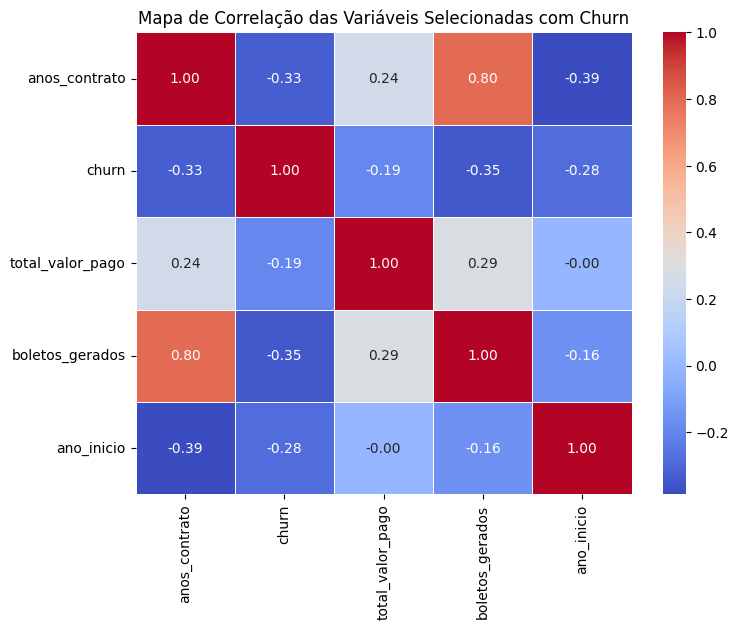

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_pandas = tabela_nova_sdf.toPandas()


# Selecionando apenas as variáveis desejadas
df_pandas_selected = df_pandas[["anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio"]]

# Calculando a matriz de correlação apenas com as variáveis selecionadas
corr_matrix_selected = df_pandas_selected.corr()

# Criando o heatmap com as variáveis filtradas
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_selected, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlação das Variáveis Selecionadas com Churn")
plt.show()



In [12]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import CoxPHFitter

def analisar_sobrevivencia_cox_todos(tabela_filtrada):
    """
    Para cada ano de 2006 até 2024, calcula o tempo médio esperado de sobrevivência usando o modelo de Cox,
    considerando dois cenários:
    1. Apenas contratos onde tipo_saida != "ATIVO".
    2. Todos os contratos.
    
    Retorna:
    - Gráfico comparando a evolução do tempo médio esperado ao longo dos anos para ambos os cenários.
    """
    
    # 🔹 Definir intervalo de anos
    ano_min = 2006
    ano_max = 2024

    resultados_filtrados = []
    resultados_todos = []

    for ano_filtro in range(ano_min, ano_max + 1):
        print(f"Calculando para contratos com data_inicio após {ano_filtro}...")

        # 🔹 Filtro 1: Apenas contratos que não são "ATIVO"
        df_filtrado = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio"))) & 
            (col("tipo_saida") != "ATIVO")
        )

        # 🔹 Filtro 2: Todos os contratos
        df_todos = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )

        # 🔹 Converter colunas para tipos adequados e transformar para Pandas
        for df, resultados in [(df_filtrado, resultados_filtrados), (df_todos, resultados_todos)]:
            df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
                   .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
            
            df_pandas = df.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()

            if df_pandas.empty:
                continue
            
            # 🔹 Aplicar modelo de Cox
            cph = CoxPHFitter()
            cph.fit(df_pandas, duration_col="anos_contrato", event_col="churn")
            
            # 🔹 Estimar o tempo médio de vida esperado usando Cox (média das expectativas de vida individuais)
            tempo_de_vida_esperado = cph.predict_expectation(df_pandas).mean()
            
            resultados.append((ano_filtro, tempo_de_vida_esperado))

    # 🔹 Criar DataFrames de resultados
    df_resultados_filtrados = pd.DataFrame(resultados_filtrados, columns=["Ano", "Tempo de Vida Esperado"])
    df_resultados_todos = pd.DataFrame(resultados_todos, columns=["Ano", "Tempo de Vida Esperado"])

    # 🔹 Criar gráfico comparativo
    fig = go.Figure()

    # 🔹 Adicionar linha para contratos sem "ATIVO"
    fig.add_trace(go.Scatter(
        x=df_resultados_filtrados["Ano"].astype(str),
        y=df_resultados_filtrados["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Sem ATIVO",
        line=dict(color="red")
    ))

    # 🔹 Adicionar linha para todos os contratos
    fig.add_trace(go.Scatter(
        x=df_resultados_todos["Ano"].astype(str),
        y=df_resultados_todos["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Todos os Contratos",
        line=dict(color="blue")
    ))

    fig.update_layout(
        title="Evolução do Tempo de Vida Esperado ao Longo dos Anos (Cox)",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Filtragem"
    )

    fig.show()


In [13]:
analisar_sobrevivencia_cox_todos(tabela_nova_sdf)

Calculando para contratos com data_inicio após 2006...
Calculando para contratos com data_inicio após 2007...
Calculando para contratos com data_inicio após 2008...
Calculando para contratos com data_inicio após 2009...
Calculando para contratos com data_inicio após 2010...
Calculando para contratos com data_inicio após 2011...
Calculando para contratos com data_inicio após 2012...
Calculando para contratos com data_inicio após 2013...
Calculando para contratos com data_inicio após 2014...
Calculando para contratos com data_inicio após 2015...
Calculando para contratos com data_inicio após 2016...
Calculando para contratos com data_inicio após 2017...
Calculando para contratos com data_inicio após 2018...
Calculando para contratos com data_inicio após 2019...
Calculando para contratos com data_inicio após 2020...
Calculando para contratos com data_inicio após 2021...
Calculando para contratos com data_inicio após 2022...
Calculando para contratos com data_inicio após 2023...
Calculando

c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\lifelines\fitters\coxph_fitter.py:1530: LinAlgWarning: Ill-conditioned matrix (rcond=5.73817e-19): result may not be accurate.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)
c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\lifelines\fitters\coxph_fitter.py:1789: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\lifelines\fitters\coxph_fitter.py:1838: RuntimeWarning: divide by zero encountered in divide
  denom = 1.0 / (risk_phi - increasing_proportion * tie_phi)
c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\lifelines\fitters\coxph_fitter.py:1847: RuntimeWarning: invalid value encountered in multiply
  a1 = einsum("ab,i->ab", risk_phi_x_

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 analisar_sobrevivencia_cox_todos(tabela_nova_sdf)                                            │
│   2                                                                                              │
│                                                                                                  │
│ in analisar_sobrevivencia_cox_todos:54                                                           │
│                                                                                                  │
│   51 │   │   │                                                                                   │
│   52 │   │   │   # 🔹 Aplicar modelo de Cox                                                      │
│   53 │   │   │   cph = CoxPHFitter()                                                             │
│ ❱ 54 │   │   │   cph.fit(df_pandas, duration_col="anos_contrato", event_col="churn")             │
│   55 │   │   │                                                                                   │
│   56 │   │   │   # 🔹 Estimar o tempo médio de vida esperado usando Cox (média das expectativ    │
│   57 │   │   │   tempo_de_vida_esperado = cph.predict_expectation(df_pandas).mean()              │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\lifelines\utils\__init__.py:56 in f                                                           │
│                                                                                                  │
│     53 │   │   @wraps(function)                                                                  │
│     54 │   │   def f(model, *args, **kwargs):                                                    │
│     55 │   │   │   cls.set_censoring_type(model, cls.RIGHT)                                      │
│ ❱   56 │   │   │   return function(model, *args, **kwargs)                                       │
│     57 │   │                                                                                     │
│     58 │   │   return f                                                                          │
│     59                                                                                           │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\lifelines\fitters\coxph_fitter.py:290 in fit                                                  │
│                                                                                                  │
│    287 │   │                                                                                     │
│    288 │   │   """                                                                               │
│    289 │   │   self.strata = utils._to_list_or_singleton(utils.coalesce(strata, self.strata))    │
│ ❱  290 │   │   self._model = self._fit_model(                                                    │
│    291 │   │   │   df,                                                                           │
│    292 │   │   │   duration_col,                                                                 │
│    293 │   │   │   event_col=event_col,                                                          │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\lifelines\fitters\coxph_fitter.py:610 in _fit_model       

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import CoxPHFitter

def analisar_sobrevivencia_cox_todos_1(tabela_filtrada):
    """
    Para cada ano de 2006 até 2024, calcula o tempo médio esperado de sobrevivência usando o modelo de Cox,
    considerando dois cenários:
    1. Apenas contratos onde tipo_saida != "ATIVO".
    2. Todos os contratos.
    
    O tempo médio esperado é calculado de duas formas:
    - Média das expectativas de vida individuais
    - Área sob a curva da função de sobrevivência base
    
    Retorna:
    - Gráfico comparando a evolução do tempo médio esperado ao longo dos anos para ambos os cenários.
    """
    
    # 🔹 Definir intervalo de anos
    ano_min = 2006
    ano_max = 2024

    resultados_filtrados = []
    resultados_todos = []

    for ano_filtro in range(ano_min, ano_max + 1):
        print(f"Calculando para contratos com data_inicio após {ano_filtro}...")

        # 🔹 Filtro 1: Apenas contratos que não são "ATIVO"
        df_filtrado = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio"))) & 
            (col("tipo_saida") != "ATIVO")
        )

        # 🔹 Filtro 2: Todos os contratos
        df_todos = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & 
            (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )

        # 🔹 Converter colunas para tipos adequados e transformar para Pandas
        for df, resultados in [(df_filtrado, resultados_filtrados), (df_todos, resultados_todos)]:
            df = df.withColumn("anos_contrato", col("anos_contrato").cast("double"))\
                   .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
            
            df_pandas = df.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()

            if df_pandas.empty:
                continue
            
            # 🔹 Aplicar modelo de Cox
            cph = CoxPHFitter()
            cph.fit(df_pandas, duration_col="anos_contrato", event_col="churn")
            
            # 🔹 Estimar tempo médio de vida esperado - MÉTODO 1: Média das expectativas individuais
            tempo_de_vida_esperado = cph.predict_expectation(df_pandas).mean()

            # 🔹 Estimar tempo médio de vida esperado - MÉTODO 2: Área sob a curva da função de sobrevivência base
            baseline_survival = cph.baseline_survival_
            tempo_de_vida_esperado_base = np.trapz(baseline_survival["baseline survival"], baseline_survival.index)
            
            resultados.append((ano_filtro, tempo_de_vida_esperado, tempo_de_vida_esperado_base))

    # 🔹 Criar DataFrames de resultados
    df_resultados_filtrados = pd.DataFrame(resultados_filtrados, columns=["Ano", "Tempo Médio Cox", "Tempo Base Cox"])
    df_resultados_todos = pd.DataFrame(resultados_todos, columns=["Ano", "Tempo Médio Cox", "Tempo Base Cox"])

    # 🔹 Criar gráfico comparativo
    fig = go.Figure()

    # 🔹 Adicionar linhas para contratos sem "ATIVO"
    fig.add_trace(go.Scatter(
        x=df_resultados_filtrados["Ano"].astype(str),
        y=df_resultados_filtrados["Tempo Médio Cox"],
        mode="lines+markers",
        name="Sem ATIVO - Média Expectativa",
        line=dict(color="red")
    ))
    fig.add_trace(go.Scatter(
        x=df_resultados_filtrados["Ano"].astype(str),
        y=df_resultados_filtrados["Tempo Base Cox"],
        mode="lines+markers",
        name="Sem ATIVO - Função Base",
        line=dict(color="orange")
    ))

    # 🔹 Adicionar linhas para todos os contratos
    fig.add_trace(go.Scatter(
        x=df_resultados_todos["Ano"].astype(str),
        y=df_resultados_todos["Tempo Médio Cox"],
        mode="lines+markers",
        name="Todos os Contratos - Média Expectativa",
        line=dict(color="blue")
    ))
    fig.add_trace(go.Scatter(
        x=df_resultados_todos["Ano"].astype(str),
        y=df_resultados_todos["Tempo Base Cox"],
        mode="lines+markers",
        name="Todos os Contratos - Função Base",
        line=dict(color="purple")
    ))

    fig.update_layout(
        title="Evolução do Tempo de Vida Esperado ao Longo dos Anos (Cox)",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Filtragem"
    )

    fig.show()


In [13]:
analisar_sobrevivencia_cox_todos_1(tabela_nova_sdf)

Calculando para contratos com data_inicio após 2006...


c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning:

Column(s) ['constant'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.


c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\lifelines\utils\__init__.py:797: RuntimeWarning:

invalid value encountered in divide

c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\lifelines\fitters\coxph_fitter.py:1530: LinAlgWarning:

Ill-conditioned matrix (rcond=0): result may not be accurate.



╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 analisar_sobrevivencia_cox_todos_1(tabela_nova_sdf)                                          │
│   2                                                                                              │
│                                                                                                  │
│ in analisar_sobrevivencia_cox_todos_1:55                                                         │
│                                                                                                  │
│   52 │   │   │   # 🔹 Aplicar modelo de Cox                                                      │
│   53 │   │   │   cph = CoxPHFitter()                                                             │
│   54 │   │   │   df_pandas["constant"] = 1  # Adicionar constante para ajuste do modelo          │
│ ❱ 55 │   │   │   cph.fit(df_pandas, duration_col="anos_contrato", event_col="churn")             │
│   56 │   │   │                                                                                   │
│   57 │   │   │   # 🔹 Estimar o tempo médio de vida esperado usando Cox (área sob a curva de     │
│   58 │   │   │   baseline_survival = cph.baseline_survival_                                      │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\lifelines\utils\__init__.py:56 in f                                                           │
│                                                                                                  │
│     53 │   │   @wraps(function)                                                                  │
│     54 │   │   def f(model, *args, **kwargs):                                                    │
│     55 │   │   │   cls.set_censoring_type(model, cls.RIGHT)                                      │
│ ❱   56 │   │   │   return function(model, *args, **kwargs)                                       │
│     57 │   │                                                                                     │
│     58 │   │   return f                                                                          │
│     59                                                                                           │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\lifelines\fitters\coxph_fitter.py:290 in fit                                                  │
│                                                                                                  │
│    287 │   │                                                                                     │
│    288 │   │   """                                                                               │
│    289 │   │   self.strata = utils._to_list_or_singleton(utils.coalesce(strata, self.strata))    │
│ ❱  290 │   │   self._model = self._fit_model(                                                    │
│    291 │   │   │   df,                                                                           │
│    292 │   │   │   duration_col,                                                                 │
│    293 │   │   │   event_col=event_col,                                                          │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\lifelines\fitters\coxph_fitter.py:610 in _fit_model       

### Tabela 2006

In [13]:
from pyspark.sql.functions import col, year

# Filtrar as linhas onde pelo menos uma das datas é de 2006 ou posterior
tabela_2006 = tabela_nova_sdf.filter(
    (year(col("data_inicio")) >= 2006)
)





In [14]:
# Filtrar as linhas onde 'data_primeiro_boleto' é menor que 2006
tabela_verificacao = tabela_2006.filter(year(col("data_primeiro_boleto")) < 2006)


tabela_verificacao.show()
# Contar quantas linhas atendem à condição
quantidade = tabela_verificacao.count()

# Exibir a quantidade de ocorrências
print(f"Existem {quantidade} registros com 'data_primeiro_boleto' menor que 2006.")

+---------+--------------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+-------------------+--------------+------------+-----------+-------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------------+-------+--------------------+---+---------------------+--------------------+-----+
|contratos|     documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|         tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|      CNPJ_CPF|CNAE_RF|          Hierarquia| uf|data_inicio_atividade|ano_inicio_atividade|idade|
+---------+-------------

In [15]:
from pyspark.sql.functions import col, year

# Filtrar as linhas onde pelo menos uma das datas é de 2006 ou posterior
tabela_filtrada_2006 = tabela_nova_sdf.filter(
    (year(col("data_inicio")) >= 2006)
)

tabela_filtrada_2006 = tabela_filtrada_2006.filter(col("documento") != "04192021000107")

In [16]:
tabela_filtrada_2006.count()

118012

In [17]:
from pyspark.sql.functions import col, sum

# Criar um DataFrame com a contagem de nulos por coluna
nulos_por_coluna = tabela_filtrada_2006.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in tabela_filtrada_2006.columns]
)

# Exibir o resultado
nulos_por_coluna.show()

+---------+---------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+----------+--------------+------------+-----------+-------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------+-------+----------+---+---------------------+--------------------+-----+
|contratos|documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|CNPJ_CPF|CNAE_RF|Hierarquia| uf|data_inicio_atividade|ano_inicio_atividade|idade|
+---------+---------+-------+-----------+----------+-----------+--------------------

In [18]:
# Contar a quantidade de ocorrências de cada churn_type e ordenar do maior para o menor
churn_count_df = (
    tabela_filtrada_2006.groupBy("tipo_saida")
    .count()
    .orderBy(F.desc("count"))
)

# Exibir o resultado
churn_count_df.show(truncate=False)

+------------------------------+-----+
|tipo_saida                    |count|
+------------------------------+-----+
|CANCELAMENTO NORMAL           |71716|
|90 DIAS BLOQUEADO             |18345|
|OUTROS                        |13196|
|ATIVO                         |12776|
|90 DIAS PRÉ CANCELADO         |1405 |
|90 DIAS PRÉ CANCELADO JURÍDICO|574  |
+------------------------------+-----+



### 2015

In [19]:
# Filtrar as linhas onde pelo menos uma das datas é de 2006 ou posterior
tabela_2015 = tabela_nova_sdf.filter(
    (year(col("data_inicio")) >= 2015)
)

In [20]:
# Filtrar as linhas onde 'data_primeiro_boleto' é menor que 2006
tabela_verificacao = tabela_2015.filter(year(col("data_primeiro_boleto")) < 2015)


tabela_verificacao.show()
# Contar quantas linhas atendem à condição
quantidade = tabela_verificacao.count()

# Exibir a quantidade de ocorrências
print(f"Existem {quantidade} registros com 'data_primeiro_boleto' menor que 2015.")

+---------+--------------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+--------------------+--------------+------------+-----------+-------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------------+-------+--------------------+---+---------------------+--------------------+-----+
|contratos|     documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|          tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|      CNPJ_CPF|CNAE_RF|          Hierarquia| uf|data_inicio_atividade|ano_inicio_atividade|idade|
+---------+-----------

In [21]:
# Filtrar as linhas onde pelo menos uma das datas é de 2006 ou posterior
tabela_filtrada_2015 = tabela_2015.filter(
    (year(col("data_inicio")) >= 2015)
)

tabela_filtrada_2015 = tabela_filtrada_2015.filter(year(col("data_primeiro_boleto")) >= 2015)

In [22]:
tabela_filtrada_2015.count()

40279

In [23]:
from pyspark.sql.functions import col, sum

# Criar um DataFrame com a contagem de nulos por coluna
nulos_por_coluna = tabela_filtrada_2015.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in tabela_filtrada_2015.columns]
)

# Exibir o resultado
nulos_por_coluna.show()

+---------+---------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+----------+--------------+------------+-----------+-------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------+-------+----------+---+---------------------+--------------------+-----+
|contratos|documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|CNPJ_CPF|CNAE_RF|Hierarquia| uf|data_inicio_atividade|ano_inicio_atividade|idade|
+---------+---------+-------+-----------+----------+-----------+--------------------

In [24]:
# Contar a quantidade de ocorrências de cada churn_type e ordenar do maior para o menor
churn_count_df = (
    tabela_filtrada_2015.groupBy("tipo_saida")
    .count()
    .orderBy(F.desc("count"))
)

# Exibir o resultado
churn_count_df.show(truncate=False)

+------------------------------+-----+
|tipo_saida                    |count|
+------------------------------+-----+
|CANCELAMENTO NORMAL           |19724|
|90 DIAS BLOQUEADO             |9332 |
|ATIVO                         |8710 |
|OUTROS                        |1799 |
|90 DIAS PRÉ CANCELADO         |549  |
|90 DIAS PRÉ CANCELADO JURÍDICO|165  |
+------------------------------+-----+



### 2020

In [25]:
# Filtrar as linhas onde pelo menos uma das datas é de 2006 ou posterior
tabela_2020 = tabela_nova_sdf.filter(
    (year(col("data_inicio")) >= 2020)
)

In [26]:
# Filtrar as linhas onde 'data_primeiro_boleto' é menor que 2006
tabela_verificacao = tabela_2020.filter(year(col("data_primeiro_boleto")) < 2020)


tabela_verificacao.show()
# Contar quantas linhas atendem à condição
quantidade = tabela_verificacao.count()

# Exibir a quantidade de ocorrências
print(f"Existem {quantidade} registros com 'data_primeiro_boleto' menor que 2020.")

+---------+--------------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+-------------------+--------------+------------+-----------+-------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------------+-------+--------------------+---+---------------------+--------------------+-----+
|contratos|     documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|         tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|      CNPJ_CPF|CNAE_RF|          Hierarquia| uf|data_inicio_atividade|ano_inicio_atividade|idade|
+---------+-------------

In [27]:
# Filtrar as linhas onde pelo menos uma das datas é de 2006 ou posterior
tabela_filtrada_2020 = tabela_2020.filter(
    (year(col("data_inicio")) >= 2020)
)

tabela_filtrada_2020 = tabela_filtrada_2020.filter(year(col("data_primeiro_boleto")) >= 2020)

In [28]:
tabela_filtrada_2020.count()

12063

In [29]:
from pyspark.sql.functions import col, sum

# Criar um DataFrame com a contagem de nulos por coluna
nulos_por_coluna = tabela_filtrada_2020.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in tabela_filtrada_2020.columns]
)

# Exibir o resultado
nulos_por_coluna.show()

+---------+---------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+----------+--------------+------------+-----------+-------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------+-------+----------+---+---------------------+--------------------+-----+
|contratos|documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|CNPJ_CPF|CNAE_RF|Hierarquia| uf|data_inicio_atividade|ano_inicio_atividade|idade|
+---------+---------+-------+-----------+----------+-----------+--------------------

In [29]:
# Contar a quantidade de ocorrências de cada churn_type e ordenar do maior para o menor
churn_count_df = (
    tabela_filtrada_2020.groupBy("tipo_saida")
    .count()
    .orderBy(F.desc("count"))
)

# Exibir o resultado
churn_count_df.show(truncate=False)

+------------------------------+-----+
|tipo_saida                    |count|
+------------------------------+-----+
|ATIVO                         |4738 |
|90 DIAS BLOQUEADO             |3583 |
|CANCELAMENTO NORMAL           |3444 |
|90 DIAS PRÉ CANCELADO         |140  |
|OUTROS                        |138  |
|90 DIAS PRÉ CANCELADO JURÍDICO|20   |
+------------------------------+-----+



## Comparação do Tempo de Permanência/ Inicio de contrato : Contratos vs. Boletos"

### Completa

In [23]:
analisar_permanencia_comparada(tabela_nova_sdf)

### 2006

In [24]:
analisar_permanencia_comparada(tabela_2006)

### 2006 Filtrado

In [25]:
analisar_permanencia_comparada(tabela_filtrada_2006)

### 2015

In [26]:
analisar_permanencia_comparada(tabela_2015)

### 2015 Filtrado

In [27]:
analisar_permanencia_comparada(tabela_filtrada_2015)

### 2020

In [28]:
analisar_permanencia_comparada(tabela_2020)

### 2020 Filtrado

In [29]:
analisar_permanencia_comparada(tabela_filtrada_2020)

### Modelo Não Paramétrico → Kaplan-Meier (KM)   / Modelo Paramétrico → Weibull Model

### Completa

In [35]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter
from scipy.special import gamma  # Para calcular a função gama

def analisar_sobrevivencia_kaplan_weibull_semativos(tabela_filtrada):
    """
    Filtra a tabela por data_primeiro_boleto menor que um determinado ano
    e aplica análise de sobrevivência com Kaplan-Meier e Weibull.
    
    Parâmetros:
    tabela_spark : DataFrame do PySpark contendo as colunas "data_primeiro_boleto", "anos_contrato" e "churn".
    ano_filtro : int, ano limite para filtrar os dados. Padrão é 2006.
    
    Retorna:
    Exibe o gráfico comparativo das funções de sobrevivência e imprime os tempos de vida esperados.
    """

    tabela_filtrada = tabela_filtrada.filter(col("tipo_saida") != "ATIVO")

    # 🔹 Converter os tipos de colunas para análise
    tabela_filtrada = (
        tabela_filtrada
        .withColumn("anos_contrato", col("anos_contrato").cast("double"))
        .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
    )

    # 🔹 Converter para Pandas
    df_pandas = tabela_filtrada.select("anos_contrato", "churn").toPandas()

    if df_pandas.empty:
        print("Nenhum dado disponível após o filtro aplicado.")
        return

    # 🔹 Aplicar Kaplan-Meier
    kmf = KaplanMeierFitter()
    kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

    # 🔹 Aplicar Weibull
    wf = WeibullFitter()
    wf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

    # 🔹 Cálculo do tempo de vida médio para Kaplan-Meier
    tempo_de_vida_esperado_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)

    # 🔹 Cálculo do tempo de vida médio para Weibull
    lambda_wf = wf.lambda_
    rho_wf = wf.rho_
    tempo_de_vida_esperado_weibull = lambda_wf * gamma(1 + 1/rho_wf)

    # 🔹 Exibir resultados
    print(f"Tempo de vida esperado (Kaplan-Meier): {tempo_de_vida_esperado_km:.2f} anos")
    print(f"Tempo de vida esperado (Weibull): {tempo_de_vida_esperado_weibull:.2f} anos")

    # 🔹 Criar gráfico interativo
    fig = go.Figure()

    # Adicionar curva de sobrevivência Weibull
    fig.add_trace(go.Scatter(
        x=wf.survival_function_.index,
        y=wf.survival_function_["Weibull_estimate"],
        mode="lines",
        name="Weibull Survival Function",
        line=dict(color="blue")
    ))

    # Adicionar curva de sobrevivência Kaplan-Meier
    fig.add_trace(go.Scatter(
        x=kmf.survival_function_.index,
        y=kmf.survival_function_["KM_estimate"],
        mode="lines",
        name="Kaplan-Meier Survival Function",
        line=dict(color="red")
    ))

    # Configurar layout
    fig.update_layout(
        title="Comparação das Curvas de Sobrevivência",
        xaxis_title="Tempo (anos)",
        yaxis_title="Probabilidade de Sobrevivência",
        template="plotly_white"
    )

    # Mostrar gráfico
    fig.show()


In [36]:
analisar_sobrevivencia_kaplan_weibull(tabela_nova_sdf)

Tempo de vida esperado (Kaplan-Meier): 4.68 anos
Tempo de vida esperado (Weibull): 4.70 anos


In [46]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter

def analisar_sobrevivencia_kaplan(tabela_filtrada):
    """
    Para cada ano a partir de 2006 até 2024, calcula o tempo médio esperado de sobrevivência usando Kaplan-Meier,
    considerando apenas contratos com data_inicio maior ou igual ao ano filtrado.

    Parâmetros:
    - tabela_filtrada: DataFrame do PySpark contendo as colunas "data_inicio", "data_primeiro_boleto", "anos_contrato" e "churn".

    Retorna:
    - Gráfico com a evolução do tempo médio esperado ao longo dos anos.
    """
    
    # 🔹 Definir intervalo de anos
    ano_min = 2006
    ano_max = 2024
    
    resultados = []
    
    for ano_filtro in range(ano_min, ano_max + 1):
        print(f"Calculando para contratos com data_inicio após {ano_filtro}...")
        
        # 🔹 Filtrar contratos com data_inicio maior ou igual ao ano selecionado e garantir que data_primeiro_boleto não seja menor que data_inicio
        df_filtrado = tabela_filtrada.filter(
            (year(col("data_inicio")) >= ano_filtro) & (year(col("data_primeiro_boleto")) >= year(col("data_inicio")))
        )
        
        # 🔹 Converter colunas para tipos adequados
        df_filtrado = (
            df_filtrado
            .withColumn("anos_contrato", col("anos_contrato").cast("double"))
            .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
        )
        
        # 🔹 Converter para Pandas
        df_pandas = df_filtrado.select("anos_contrato", "churn").toPandas()
        
        if df_pandas.empty:
            continue
        
        # 🔹 Aplicar Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])
        
        # 🔹 Calcular o tempo de vida esperado
        tempo_de_vida_esperado = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        
        resultados.append((ano_filtro, tempo_de_vida_esperado))
    
    # 🔹 Converter resultados em DataFrame
    df_resultados = pd.DataFrame(resultados, columns=["Ano", "Tempo de Vida Esperado"])
    
    # 🔹 Criar gráfico
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df_resultados["Ano"],
        y=df_resultados["Tempo de Vida Esperado"],
        mode="lines+markers",
        name="Tempo Médio Esperado",
        line=dict(color="red")
    ))
    
    fig.update_layout(
        title="Evolução do Tempo de Vida Esperado ao Longo dos Anos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white"
    )
    
    fig.show()


In [47]:
analisar_sobrevivencia_kaplan(tabela_nova_sdf)

Calculando para contratos com data_inicio após 2006...


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 analisar_sobrevivencia_kaplan(tabela_nova_sdf)                                               │
│   2                                                                                              │
│                                                                                                  │
│ in analisar_sobrevivencia_kaplan:42                                                              │
│                                                                                                  │
│   39 │   │   )                                                                                   │
│   40 │   │                                                                                       │
│   41 │   │   # 🔹 Converter para Pandas                                                          │
│ ❱ 42 │   │   df_pandas = df_filtrado.select("anos_contrato", "churn").toPandas()                 │
│   43 │   │                                                                                       │
│   44 │   │   if df_pandas.empty:                                                                 │
│   45 │   │   │   continue                                                                        │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\pyspark\sql\connect\dataframe.py:1778 in toPandas                                             │
│                                                                                                  │
│   1775 │                                                                                         │
│   1776 │   def toPandas(self) -> "pandas.DataFrame":                                             │
│   1777 │   │   query = self._plan.to_proto(self._session.client)                                 │
│ ❱ 1778 │   │   return self._session.client.to_pandas(query, self._plan.observations)             │
│   1779 │                                                                                         │
│   1780 │   toPandas.__doc__ = PySparkDataFrame.toPandas.__doc__                                  │
│   1781                                                                                           │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\pyspark\sql\connect\client\core.py:998 in to_pandas                                           │
│                                                                                                  │
│    995 │   │   logger.info(f"Executing plan {self._proto_to_string(plan)}")                      │
│    996 │   │   req = self._execute_plan_request_with_metadata()                                  │
│    997 │   │   req.plan.CopyFrom(plan)                                                           │
│ ❱  998 │   │   (self_destruct_conf,) = self.get_config_with_defaults(                            │
│    999 │   │   │   ("spark.sql.execution.arrow.pyspark.selfDestruct.enabled", "false"),          │
│   1000 │   │   )                                                                                 │
│   1001 │   │   self_destruct = cast(str, self_destruct_conf).lower() == "true"                   │
│                                                                                                  │
│ c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packag │
│ es\pyspark\sql\connect\client\core.py:1582 in get_config_wit

### 2006 Filtrada

In [37]:
analisar_sobrevivencia_kaplan_weibull_semativos(tabela_filtrada_2006)

Tempo de vida esperado (Kaplan-Meier): 3.20 anos
Tempo de vida esperado (Weibull): 3.24 anos


In [31]:
analisar_sobrevivencia_kaplan_weibull(tabela_filtrada_2006)

Tempo de vida esperado (Kaplan-Meier): 4.11 anos
Tempo de vida esperado (Weibull): 4.19 anos


### 2015 Filtrada

In [38]:
analisar_sobrevivencia_kaplan_weibull_semativos(tabela_filtrada_2015)

Tempo de vida esperado (Kaplan-Meier): 2.09 anos
Tempo de vida esperado (Weibull): 2.13 anos


In [32]:
analisar_sobrevivencia_kaplan_weibull(tabela_filtrada_2015)

Tempo de vida esperado (Kaplan-Meier): 3.25 anos
Tempo de vida esperado (Weibull): 3.55 anos


### 2020 Filtrada

In [39]:
analisar_sobrevivencia_kaplan_weibull_semativos(tabela_filtrada_2020)

Tempo de vida esperado (Kaplan-Meier): 1.40 anos
Tempo de vida esperado (Weibull): 1.44 anos


In [33]:
analisar_sobrevivencia_kaplan_weibull(tabela_filtrada_2020)

Tempo de vida esperado (Kaplan-Meier): 2.43 anos
Tempo de vida esperado (Weibull): 2.91 anos


 ### Modelo Paramétrico → Weibull Model Com covariaveis

### Completa

In [35]:
from lifelines import WeibullAFTFitter
from sklearn.preprocessing import StandardScaler

def analisar_sobrevivencia_weibull(tabela_filtrada, variaveis):
    """
    Aplica análise de sobrevivência utilizando o modelo Weibull AFT com múltiplas variáveis.
    """
    # Converter os tipos de colunas para análise
    tabela_filtrada = (
        tabela_filtrada
        .withColumn("anos_contrato", col("anos_contrato").cast("double"))
        .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
    )
    
    # Selecionar colunas relevantes
    colunas_selecionadas = ["anos_contrato", "churn"] + variaveis
    df_pandas = tabela_filtrada.select(colunas_selecionadas).toPandas()
    
    if df_pandas.empty:
        print("Nenhum dado disponível após o filtro aplicado.")
        return
    
    # Normalizar variáveis explicativas
    scaler = StandardScaler()
    df_pandas[variaveis] = scaler.fit_transform(df_pandas[variaveis])

    # Ajustar modelo Weibull com regressão
    aft = WeibullAFTFitter()
    aft.fit(df_pandas, duration_col="anos_contrato", event_col="churn")

    # Obter o tempo de vida esperado ajustado
    tempo_de_vida_esperado_weibull = aft.predict_expectation(df_pandas[variaveis])
    
    print(f"Tempo de vida esperado médio (Weibull com variáveis): {tempo_de_vida_esperado_weibull.mean():.2f} anos")

    # Criar gráfico interativo
    fig = go.Figure()

    # Adicionar curva de sobrevivência Weibull
    fig.add_trace(go.Scatter(
        x=aft.predict_survival_function(df_pandas[variaveis]).index,
        y=aft.predict_survival_function(df_pandas[variaveis]).mean(axis=1),
        mode="lines",
        name="Weibull Survival Function",
        line=dict(color="blue")
    ))

    # Configurar layout
    fig.update_layout(
        title="Curva de Sobrevivência - Modelo Weibull com Variáveis",
        xaxis_title="Tempo (anos)",
        yaxis_title="Probabilidade de Sobrevivência",
        template="plotly_white"
    )

    # Mostrar gráfico
    fig.show()



In [ ]:
#variaveis_adicionais = ["boletos_gerados", "total_valor_pago", "ano_inicio"]
#analisar_sobrevivencia_weibull(tabela_nova_sdf, variaveis_adicionais)

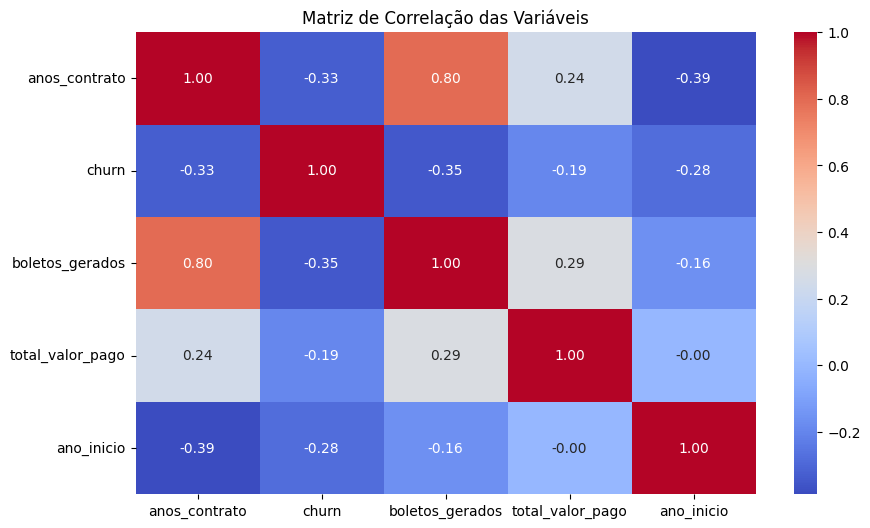

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

variaveis_adicionais = ["boletos_gerados", "total_valor_pago", "ano_inicio"]

# Selecionar colunas relevantes
colunas_selecionadas = ["anos_contrato", "churn"] + variaveis_adicionais
df_pandas = tabela_nova_sdf.select(colunas_selecionadas).toPandas()

correlation_matrix = df_pandas.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Variáveis")
plt.show()

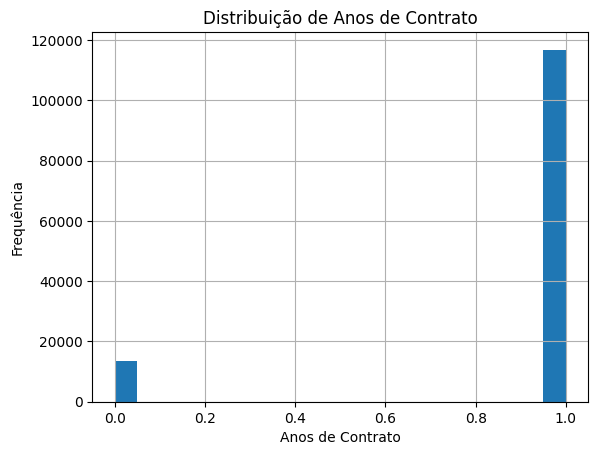

In [39]:
df_pandas["churn"].hist(bins=20)
plt.xlabel("Anos de Contrato")
plt.ylabel("Frequência")
plt.title("Distribuição de Anos de Contrato")
plt.show()

### 2006 Filtrada

### 2015 Filtrada

### 2020 Filtrada

### Modelo Semiparamétrico → Cox Proportional Hazards Model  + idade () eliminei algumas linhas

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter
from scipy.special import gamma  # Para calcular a função gama
import matplotlib.pyplot as plt

def analisar_sobrevivencia_kaplan_weibull_cox(tabela_filtrada):
    """
    Filtra a tabela excluindo clientes com 'tipo_saida' igual a 'ATIVO'
    e aplica análise de sobrevivência com Kaplan-Meier, Weibull e Cox.
    
    Parâmetros:
    tabela_filtrada : DataFrame do PySpark contendo as colunas "anos_contrato", "churn", "tipo_saida".
    
    Retorna:
    Exibe gráficos comparativos das funções de sobrevivência e imprime os tempos de vida esperados.
    """

    

    # 🔹 Converter os tipos de colunas para análise
    tabela_filtrada = (
        tabela_filtrada
        .withColumn("anos_contrato", col("anos_contrato").cast("double"))
        .withColumn("churn", when(col("churn") == 1, 1).otherwise(0).cast("int"))
    )

    # 🔹 Converter para Pandas
    df_pandas = tabela_filtrada.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados").toPandas()

    if df_pandas.empty:
        print("Nenhum dado disponível após o filtro aplicado.")
        return

    # 🔹 Aplicar Kaplan-Meier
    kmf = KaplanMeierFitter()
    kmf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

    # 🔹 Aplicar Weibull
    wf = WeibullFitter()
    wf.fit(df_pandas["anos_contrato"], event_observed=df_pandas["churn"])

    # 🔹 Aplicar Cox
    cph = CoxPHFitter()
    df_cox = df_pandas[["anos_contrato", "churn", "total_valor_pago", "boletos_gerados","ano_inicio"]]
    cph.fit(df_cox, duration_col="anos_contrato", event_col="churn")

    # 🔹 Cálculo do tempo de vida médio para Kaplan-Meier
    tempo_de_vida_esperado_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)

    # 🔹 Cálculo do tempo de vida médio para Weibull
    lambda_wf = wf.lambda_
    rho_wf = wf.rho_
    tempo_de_vida_esperado_weibull = lambda_wf * gamma(1 + 1/rho_wf)

    # 🔹 Cálculo do tempo de vida esperado com Cox (área abaixo da curva)
    baseline_survival = cph.baseline_survival_
    tempo_de_vida_esperado_cox = np.trapz(baseline_survival["baseline survival"], baseline_survival.index)

    # 🔹 Exibir resultados
    print(f"Tempo de vida esperado (Kaplan-Meier): {tempo_de_vida_esperado_km:.2f} anos")
    print(f"Tempo de vida esperado (Weibull): {tempo_de_vida_esperado_weibull:.2f} anos")
    print(f"Tempo de vida esperado (Cox): {tempo_de_vida_esperado_cox:.2f} anos")

    # 🔹 Criar gráfico interativo (Kaplan-Meier e Weibull)
    fig = go.Figure()

    # Adicionar curva de sobrevivência Weibull
    fig.add_trace(go.Scatter(
        x=wf.survival_function_.index,
        y=wf.survival_function_["Weibull_estimate"],
        mode="lines",
        name="Weibull Survival Function",
        line=dict(color="blue")
    ))

    # Adicionar curva de sobrevivência Kaplan-Meier
    fig.add_trace(go.Scatter(
        x=kmf.survival_function_.index,
        y=kmf.survival_function_["KM_estimate"],
        mode="lines",
        name="Kaplan-Meier Survival Function",
        line=dict(color="red")
    ))

    # Configurar layout
    fig.update_layout(
        title="Comparação das Curvas de Sobrevivência (Kaplan-Meier vs Weibull)",
        xaxis_title="Tempo (anos)",
        yaxis_title="Probabilidade de Sobrevivência",
        template="plotly_white"
    )

    # Mostrar gráfico interativo
    fig.show()

    # 🔹 Criar gráfico da curva de sobrevivência de Cox
    plt.figure(figsize=(8, 6))
    plt.plot(baseline_survival.index, baseline_survival["baseline survival"], label="Curva de Sobrevivência (Cox)", color="green")
    plt.xlabel("Tempo (anos)")
    plt.ylabel("Probabilidade de Sobrevivência")
    plt.title("Curva de Sobrevivência - Modelo de Cox")
    plt.legend()
    plt.grid()
    plt.show()


Tempo de vida esperado (Kaplan-Meier): 4.11 anos
Tempo de vida esperado (Weibull): 4.19 anos
Tempo de vida esperado (Cox): 3.17 anos


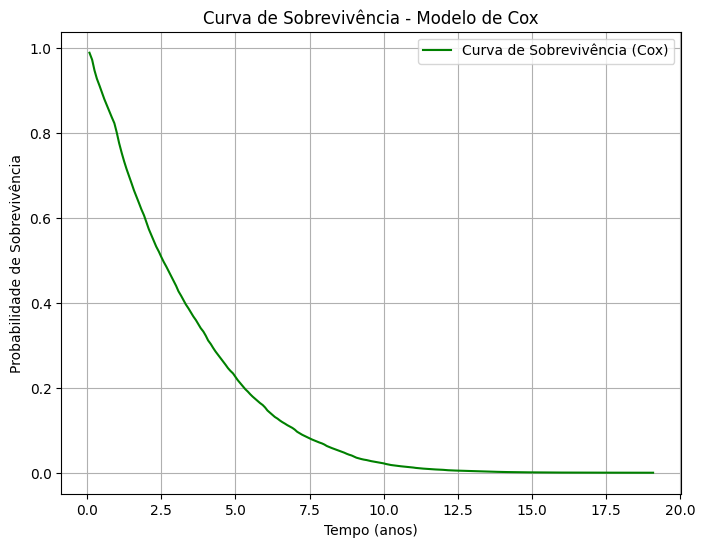

In [43]:
analisar_sobrevivencia_kaplan_weibull_cox(tabela_filtrada_2006)

### Completa

In [41]:
from lifelines import CoxPHFitter
from pyspark.sql.functions import col
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def aplicar_modelo_cox(df_spark):
    """
    Função para ajustar um modelo de Cox usando dados do PySpark convertidos para Pandas.
    
    Parâmetros:
    df_spark (DataFrame PySpark): DataFrame contendo os dados filtrados.
    
    Retorna:
    tempo_de_vida_esperado_cox (float): Estimativa do tempo de vida esperado em anos.
    """
    # Ajustar os dados no PySpark para remover nulos e converter tipos
    df_spark = df_spark.withColumn("anos_contrato", col("anos_contrato").cast("double"))
    df_spark = df_spark.withColumn("churn", col("churn").cast("int"))
    df_spark = df_spark.withColumn("total_valor_pago", col("total_valor_pago").cast("double"))
    
    # Converter para Pandas
    df_pandas = df_spark.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()
    
    # Criar DataFrame para o modelo de Cox
    df_cox = df_pandas[["anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio"]]
    
    # Aplicar modelo de Cox
    cph = CoxPHFitter()
    cph.fit(df_cox, duration_col="anos_contrato", event_col="churn")
    
    # Mostrar os coeficientes do modelo
    cph.print_summary()
    
    # Plotar hazard ratios
    cph.plot()
    plt.show()
    
    # Obter a função de sobrevivência base do modelo de Cox
    baseline_survival = cph.baseline_survival_
    
    # Estimar o tempo de vida médio como a área abaixo da curva de sobrevivência base
    tempo_de_vida_esperado_cox = np.trapz(baseline_survival["baseline survival"], baseline_survival.index)
    
    print(f"Tempo de vida esperado (Modelo de Cox): {tempo_de_vida_esperado_cox:.2f} anos")
    
    return tempo_de_vida_esperado_cox


In [ ]:
from lifelines import CoxPHFitter
from pyspark.sql.functions import col
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def aplicar_modelo_cox_2(df_spark):
    """
    Ajusta um modelo de Cox e plota a curva de sobrevivência.

    Parâmetros:
    df_spark (DataFrame PySpark): DataFrame contendo os dados filtrados.

    Retorna:
    tempo_de_vida_esperado_cox (float): Estimativa do tempo de vida esperado em anos.
    """
    # Ajustar os dados no PySpark para remover nulos e converter tipos
    df_spark = df_spark.withColumn("anos_contrato", col("anos_contrato").cast("double"))
    df_spark = df_spark.withColumn("churn", col("churn").cast("int"))
    df_spark = df_spark.withColumn("total_valor_pago", col("total_valor_pago").cast("double"))
    
    # Converter para Pandas
    df_pandas = df_spark.select("anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio").toPandas()
    
    # Criar DataFrame para o modelo de Cox
    df_cox = df_pandas[["anos_contrato", "churn", "total_valor_pago", "boletos_gerados", "ano_inicio"]]
    
    # Aplicar modelo de Cox
    cph = CoxPHFitter()
    cph.fit(df_cox, duration_col="anos_contrato", event_col="churn")
    
    # Mostrar os coeficientes do modelo
    cph.print_summary()
    
    # Plotar os hazard ratios
    cph.plot()
    plt.show()
    
    # Obter a curva de sobrevivência base do modelo de Cox
    baseline_survival = cph.baseline_survival_
    
    # Plotar a curva de sobrevivência
    plt.figure(figsize=(8, 6))
    plt.plot(baseline_survival.index, baseline_survival["baseline survival"], label="Curva de Sobrevivência (Cox)")
    plt.xlabel("Tempo (anos)")
    plt.ylabel("Probabilidade de Sobrevivência")
    plt.title("Curva de Sobrevivência - Modelo de Cox")
    plt.legend()
    plt.grid()
    plt.show()
    
    # Calcular o tempo de vida médio (área abaixo da curva de sobrevivência base)
    tempo_de_vida_esperado_cox = np.trapz(baseline_survival["baseline survival"], baseline_survival.index)
    
    print(f"Tempo de vida esperado (Modelo de Cox): {tempo_de_vida_esperado_cox:.2f} anos")
    
    return tempo_de_vida_esperado_cox


<lifelines.CoxPHFitter: fitted with 130225 total observations, 13455 right-censored observations>
             duration col = 'anos_contrato'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 130225
number of events observed = 116770
   partial log-likelihood = -1228252.28
         time fit was run = 2025-02-18 18:08:51 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
total_valor_pago -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
boletos_gerados  -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
ano_inicio        0.07      1.08      0.00            0.07            0.08                1.08                1.08

                  cmp to       z      p  -log2(p)
covariate                                        
total_valor_pago    0.00  -31.88 <0.005    738.46
boletos_gerados     0.00 -182.60 <0.005       inf
ano_inicio          0.00  130.21 <0.005       inf
---
Concordance = 0.81
Partial AIC = 2456510.56
log-likelihood ratio test = 86671.10 on 3 df
-log2(p) of ll-ratio test = inf

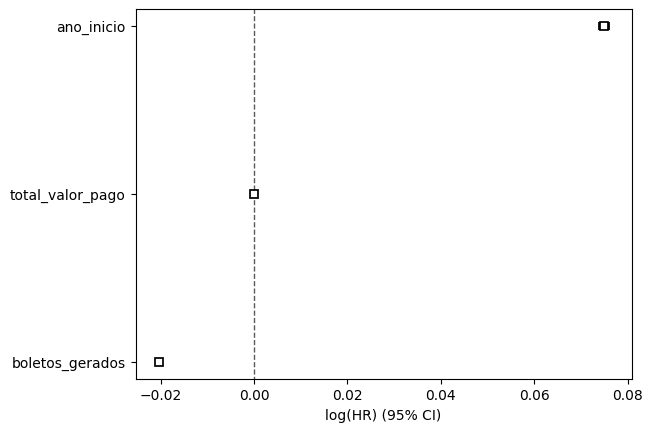

Tempo de vida esperado (Modelo de Cox): 3.56 anos


3.562382091214935

In [42]:
aplicar_modelo_cox(tabela_nova_sdf)

### 2006

<lifelines.CoxPHFitter: fitted with 118012 total observations, 12775 right-censored observations>
             duration col = 'anos_contrato'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 118012
number of events observed = 105237
   partial log-likelihood = -1097092.21
         time fit was run = 2025-02-18 18:11:09 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
total_valor_pago -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
boletos_gerados  -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
ano_inicio        0.04      1.04      0.00            0.03            0.04                1.03                1.04

                  cmp to       z      p  -log2(p)
covariate                                        
total_valor_pago    0.00  -24.50 <0.005    438.06
boletos_gerados     0.00 -197.08 <0.005       inf
ano_inicio          0.00   47.88 <0.005       inf
---
Concordance = 0.84
Partial AIC = 2194190.41
log-likelihood ratio test = 80188.18 on 3 df
-log2(p) of ll-ratio test = inf

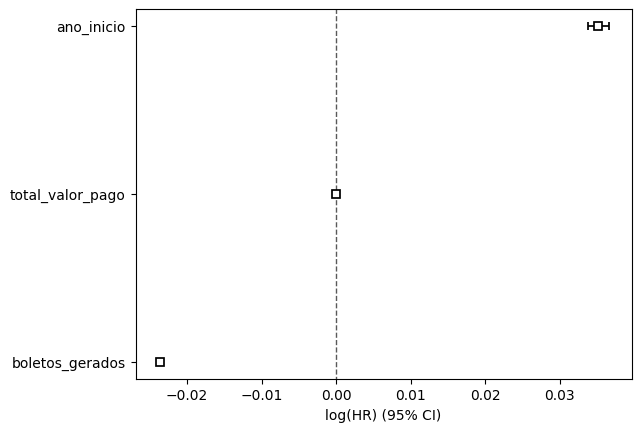

Tempo de vida esperado (Modelo de Cox): 3.13 anos


3.132598053126553

In [43]:
aplicar_modelo_cox(tabela_filtrada_2006)

### 2015

<lifelines.CoxPHFitter: fitted with 40279 total observations, 8708 right-censored observations>
             duration col = 'anos_contrato'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 40279
number of events observed = 31571
   partial log-likelihood = -295905.15
         time fit was run = 2025-02-18 18:12:33 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
total_valor_pago -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
boletos_gerados  -0.04      0.96      0.00           -0.04           -0.04                0.96                0.96
ano_inicio       -0.03      0.97      0.00           -0.04           -0.03                0.97                0.97

                  cmp to       z      p  -log2(p)
covariate                                        
total_valor_pago    0.00   -9.98 <0.005     75.58
boletos_gerados     0.00 -123.59 <0.005       inf
ano_inicio          0.00  -13.23 <0.005    130.32
---
Concordance = 0.87
Partial AIC = 591816.30
log-likelihood ratio test = 29157.71 on 3 df
-log2(p) of ll-ratio test = inf

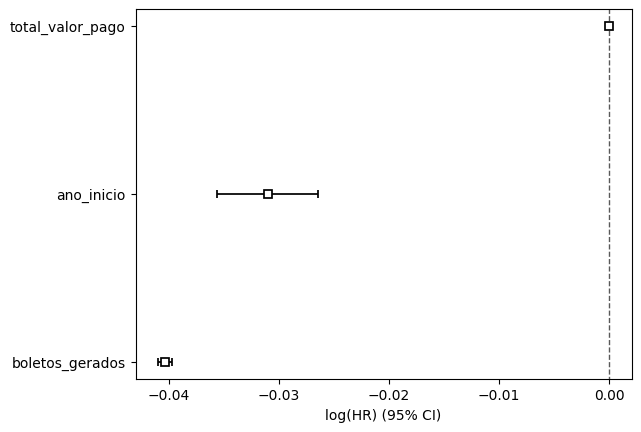

Tempo de vida esperado (Modelo de Cox): 2.58 anos


2.5793292403867913

In [44]:
aplicar_modelo_cox(tabela_filtrada_2015)

### 2020

<lifelines.CoxPHFitter: fitted with 12063 total observations, 4739 right-censored observations>
             duration col = 'anos_contrato'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 12063
number of events observed = 7324
   partial log-likelihood = -59730.80
         time fit was run = 2025-02-18 18:13:58 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
total_valor_pago -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
boletos_gerados  -0.07      0.93      0.00           -0.07           -0.07                0.93                0.93
ano_inicio       -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97

                  cmp to      z      p  -log2(p)
covariate                                       
total_valor_pago    0.00  -5.46 <0.005     24.36
boletos_gerados     0.00 -64.80 <0.005       inf
ano_inicio          0.00  -5.08 <0.005     21.30
---
Concordance = 0.89
Partial AIC = 119467.60
log-likelihood ratio test = 7416.39 on 3 df
-log2(p) of ll-ratio test = inf

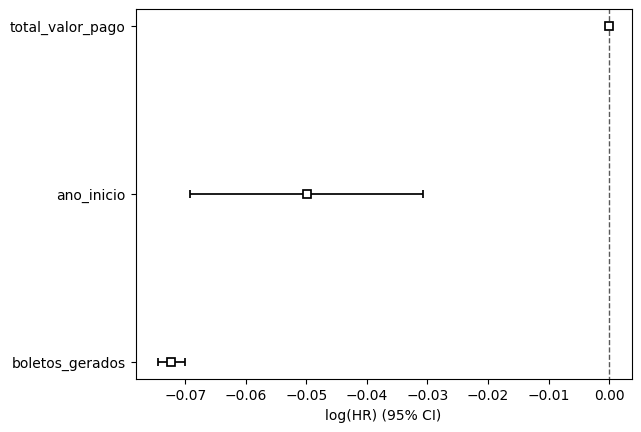

Tempo de vida esperado (Modelo de Cox): 2.04 anos


2.0431061435383873

In [45]:
aplicar_modelo_cox(tabela_filtrada_2020)